In [133]:
import triangle
import math
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from collections import defaultdict
from shapely.geometry import Point, Polygon, LineString, MultiLineString
from shapely.ops import unary_union

In [143]:
def cast_rays_with_holes(polygon, viewpoint, n_rays=500):
    ray_points = []
    #angles = np.linspace(0, 2 * np.pi, n_rays)
    angles = []
    
    # Extract exterior and holes
    edges = []
    coords = list(polygon.exterior.coords)
    edges.extend(zip(coords[:-1], coords[1:]))
    
    all_vertices = coords

    for interior in polygon.interiors:
        coords = list(interior.coords)
        all_vertices += coords
        edges.extend(zip(coords[:-1], coords[1:]))

    #print(all_vertices)
    
    for vx, vy in all_vertices:
        temp = math.atan2(vy - viewpoint[1], vx - viewpoint[0])
        #print(temp)
        angles.append(temp + 0.00001)
        angles.append(temp)
        angles.append(temp - 0.00001)
    
    angles.sort()

    for angle in angles:
        dx, dy = np.cos(angle), np.sin(angle)
        far_point = (viewpoint[0] + dx * 1000, viewpoint[1] + dy * 1000)
        near_point = (viewpoint[0] + dx * 0.01, viewpoint[1] + dy * 0.01)
        if not polygon.contains(Point(near_point)): # Fix the problem where you are along a boundary
            ray_points.append(viewpoint) 
        else:
            ray = LineString([near_point, far_point])
            min_dist = float('inf')
            closest_pt = None
            for seg_start, seg_end in edges:
                edge = LineString([seg_start, seg_end])
                if ray.intersects(edge):
                    pt = ray.intersection(edge)
                    if isinstance(pt, Point):
                        dist = Point(viewpoint).distance(pt)
                        if dist < min_dist:
                            min_dist = dist
                            closest_pt = pt
            if closest_pt:
                #ray_points.append((closest_pt.x, closest_pt.y))
                ray_points.append((round(closest_pt.x, 3), round(closest_pt.y, 3)))
            
    return ray_points


In [145]:
def is_window(polygon, point1, point2):
    """ Points 1 and 2 are an edge on the visibilty polygon and we would like to 
    know if they are a window, or if they are on the edge of a boundry or hole """
    
    if math.hypot(point1[0]-point2[0], point1[1]-point2[1]) < 0.0001:
        return False # Too short a segment to be a real window

    
    boundary_coords = list(polygon.exterior.coords)
    edges = [LineString([boundary_coords[i], boundary_coords[i+1]]) for i in range(len(boundary_coords) - 1)]
    
    
    for interior in list(polygon.interiors):
        pts = list(interior.coords)
        edges += [LineString([pts[i], pts[i+1]]) for i in range(len(pts) - 1)]
    
    line1 = LineString([point1, point2])
    for boundary_line in edges:
        if boundary_line.intersects(line1) and boundary_line.intersection(line1).geom_type == 'LineString':
            return False
    
    return True


In [147]:
def get_windows(polygon, vis_polygon):
    vis_coords= list(vis_polygon.exterior.coords)

    # Create a list of LineStrings for each segment
    vis_segments = [LineString(vis_coords[i:i+2]) for i in range(len(vis_coords) - 1)]
    poly_coords = list(polygon.exterior.coords)
    poly_segments = [LineString(poly_coords[i:i+2]) for i in range(len(poly_coords) - 1)]
    for interior in list(polygon.interiors):
        pts = list(interior.coords)
        poly_segments += [LineString([pts[i], pts[i+1]]) for i in range(len(pts) - 1)]
    
    multi_line_vis = unary_union(vis_segments)
    multi_line_poly = unary_union(poly_segments)
    
    windows_segments = multi_line_vis.difference(multi_line_poly)

    return windows_segments
    

In [177]:
# Define outer polygon and hole
outer = [(0,0), (10,0), (10,10), (0,10)]
holes = [[(4,2), (6,4), (4,6), (2,4)],
        [(2,6), (3,6), (3,7), (2,7)]]

polygon = Polygon(outer, holes)
viewpoint = (2.75,5) #(1,3.5)
destination = [7, 6]

# Compute visibility
vis_points = cast_rays_with_holes(polygon, viewpoint)
vis_polygon = Polygon(vis_points)


In [179]:
#Find all the windows for the next step
windows_segments = get_windows(polygon, vis_polygon)
windows = []
for window in windows_segments.geoms:
    # Add the start point of the current LineString
    windows.append([window.coords[0], window.coords[-1]])

In [181]:
windows

[[(0.0, 1.333), (2.0, 4.0)],
 [(2.824, 4.824), (2.898, 4.898)],
 [(2.898, 4.898), (2.941, 4.941)],
 [(4.0, 6.0), (9.0, 10.0)],
 [(4.0, 10.0), (3.0, 6.0)],
 [(2.0, 6.0), (0.0, 8.667)]]

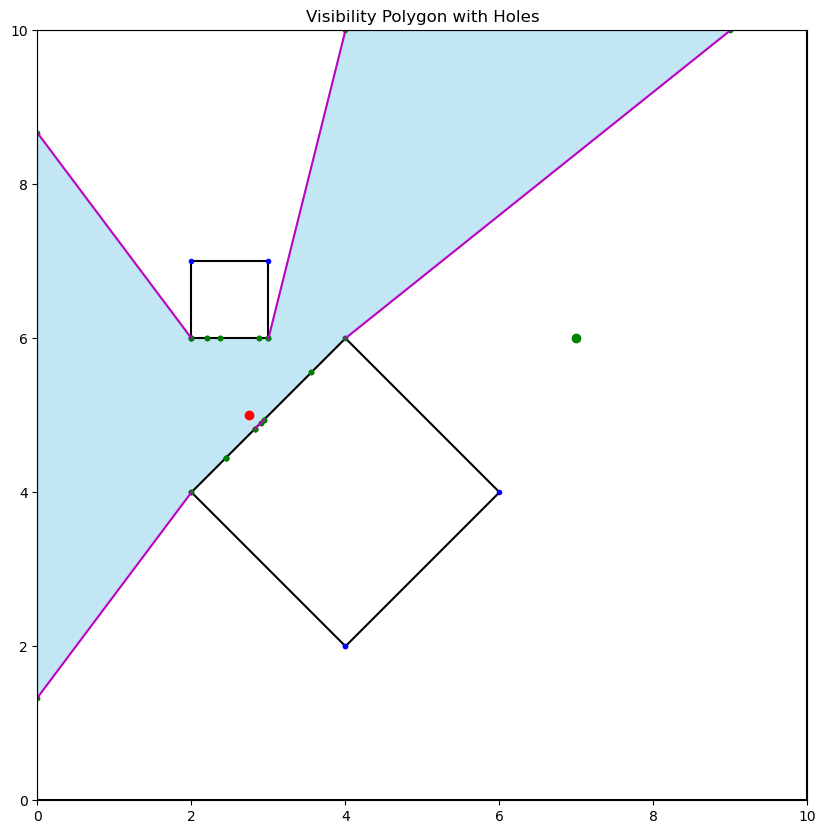

In [183]:
# Plotting
fig, ax = plt.subplots(figsize=(10, 10))
ox, oy = zip(*polygon.exterior.coords)
ax.plot(ox, oy, 'k-', label='Outer Boundary')

for interior in polygon.interiors:
    hx, hy = zip(*interior.coords)
    ax.plot(hx, hy, 'k-', label='Hole')
    ax.plot(hx, hy, 'b.', label='Vertices')    

vx, vy = zip(*vis_polygon.exterior.coords)
ax.plot(vx,vy, 'g.')
ax.fill(vx, vy, color='skyblue', alpha=0.5, label='Visibility')

for item in windows:
    px,py = zip(*item)
    ax.plot(px, py, "m-")

ax.plot(*viewpoint, 'ro', label='Viewpoint')
ax.plot(destination[0], destination[1], 'go')
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_aspect('equal')
plt.title("Visibility Polygon with Holes")
#plt.legend()
plt.show()

In [185]:
unvisited_polygon = polygon - vis_polygon

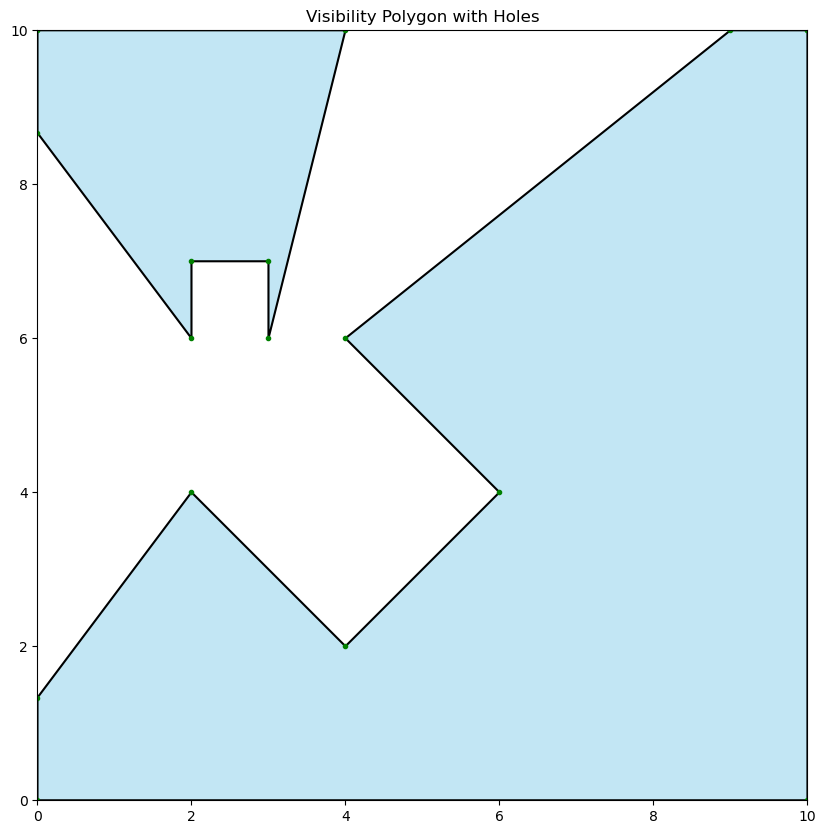

In [187]:
# Plotting
fig, ax = plt.subplots(figsize=(10, 10))

for poly in unvisited_polygon.geoms:
    ox, oy = zip(*poly.exterior.coords)
    ax.plot(ox, oy, 'k-', label='Outer Boundary')

    for interior in poly.interiors:
        hx, hy = zip(*interior.coords)
        ax.plot(hx, hy, 'k-', label='Hole')
        ax.plot(hx, hy, 'b.', label='Vertices')    

    vx, vy = zip(*poly.exterior.coords)
    ax.plot(vx,vy, 'g.')
    ax.fill(vx, vy, color='skyblue', alpha=0.5, label='Visibility')

ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_aspect('equal')
plt.title("Visibility Polygon with Holes")
#plt.legend()
plt.show()

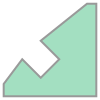

In [189]:
poly0 = unvisited_polygon.geoms[0]
poly0

In [191]:
windows0 = []
for segment in windows:
    if (poly0.touches(Point(segment[0])) and poly0.touches(Point(segment[1]))):
        windows0 += segment

In [193]:
windows0

[(0.0, 1.333), (2.0, 4.0), (4.0, 6.0), (9.0, 10.0)]

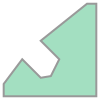

In [195]:
new_vis_poly = Polygon()
for vis_point in windows0:
    new_vis_points = cast_rays_with_holes(poly0, vis_point)
    temp_poly = Polygon(new_vis_points)
    new_vis_poly = new_vis_poly.union(temp_poly)

new_vis_poly

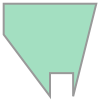

In [197]:
poly1 = unvisited_polygon.geoms[1]
poly1


In [171]:
from shapely.ops import unary_union
new_vis_polygon = Polygon()
for view_point in windows0:
    new_vis_points = cast_rays_with_holes(poly0, view_point)
    new_vis_polygon = unary_union([new_vis_polygon, Polygon(new_vis_points)])

In [173]:
windows1 = []
for segment in windows:
    if (poly1.touches(Point(segment[0])) and poly1.touches(Point(segment[1]))):
        windows1 += segment
windows1

[(5.0, 10.0), (3.0, 6.0), (2.0, 6.0), (0.0, 10.0)]

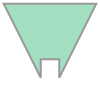

In [175]:
new_vis_poly = Polygon()
for vis_point in windows1:
    new_vis_points = cast_rays_with_holes(poly1, vis_point)
    temp_poly = Polygon(new_vis_points)
    new_vis_poly = new_vis_poly.union(temp_poly)

new_vis_poly

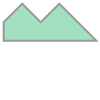

In [17]:
new_vis_polygon

In [18]:
# Combine all points
points = outer + [vert for hole in holes for vert in hole]

# Define segments (edges) for outer boundary
segments_outer = [[i, (i + 1) % len(outer)] for i in range(len(outer))]

# Define segments for hole (offset by len(outer))
offset = len(outer)
segments_holes = []
for hole in holes:
    segments_holes += [(offset + i, offset + (i + 1) % len(hole)) for i in range(len(hole))]
    offset += len(hole)

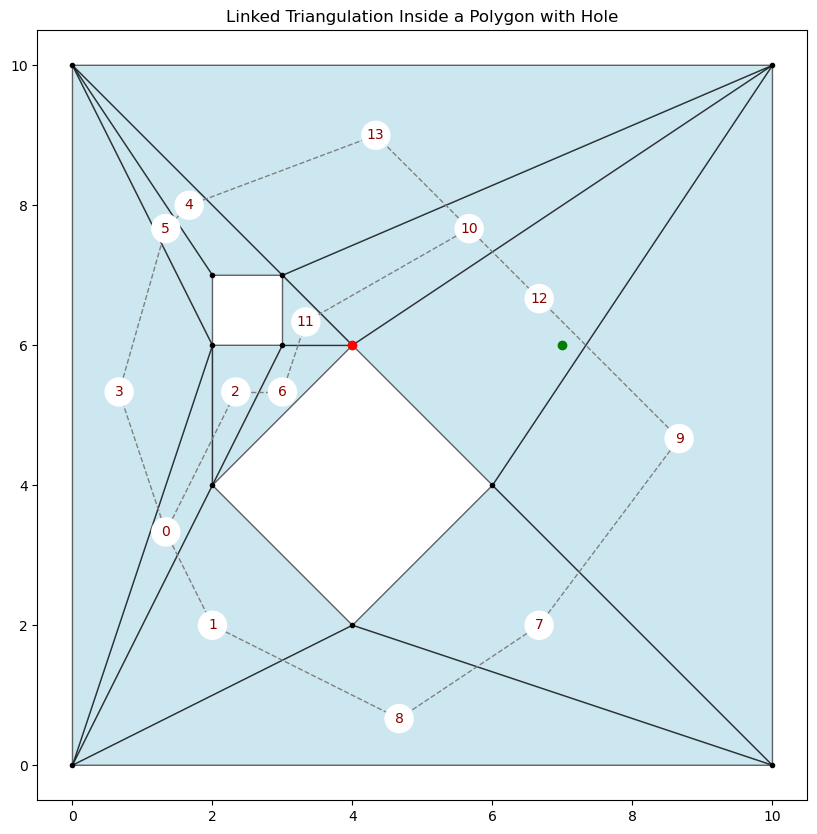

In [19]:
# Combine all segments
segments = segments_outer + segments_holes

# Define a point inside the hole to mark it
hole_points = [(4, 4), (2.5, 6.5)]

# Prepare input for triangle
A = {
    'vertices': points,
    'segments': segments,
    'holes': hole_points
}

# Triangulate with 'p' for PSLG
B = triangle.triangulate(A, 'p')

# Compute centroids
centroids = [np.mean(B['vertices'][tri], axis=0) for tri in B['triangles']]

# Build adjacency map
adjacency = defaultdict(set)
triangles = B['triangles']
for i, tri_i in enumerate(triangles):
    edges_i = {frozenset((tri_i[j], tri_i[(j + 1) % 3])) for j in range(3)}
    for j in range(i + 1, len(triangles)):
        tri_j = triangles[j]
        edges_j = {frozenset((tri_j[k], tri_j[(k + 1) % 3])) for k in range(3)}
        if edges_i & edges_j:
            adjacency[i].add(j)
            adjacency[j].add(i)

# Prepare connection pairs
connections = [(i, j) for i, neighbors in adjacency.items() for j in neighbors if i < j]

# Plot manually using matplotlib
plt.figure(figsize=(10, 10))
for i, tri in enumerate(B['triangles']):
    pts = B['vertices'][tri]
    polygon = plt.Polygon(pts, edgecolor='black', facecolor='lightblue', alpha=0.6)
    plt.gca().add_patch(polygon)
    # Compute centroid
    centroid = np.mean(pts, axis=0)

    # Add white circle background
    circle = patches.Circle(centroid, radius=0.2, color='white', zorder=3)
    plt.gca().add_patch(circle)

    # Add triangle index text
    plt.text(centroid[0], centroid[1], str(i), ha='center', va='center',
             fontsize=10, color='darkred', zorder=4)

# Draw dashed lines between adjacent centroids
for i, neighbors in adjacency.items():
    for j in neighbors:
        if i < j:  # Avoid duplicate lines
            x_vals = [centroids[i][0], centroids[j][0]]
            y_vals = [centroids[i][1], centroids[j][1]]
            plt.plot(x_vals, y_vals, linestyle='--', color='gray', linewidth=1, zorder=2)


# Plot vertices
x, y = zip(*B['vertices'])
plt.plot(x, y, 'ko', markersize=3)
plt.plot(*viewpoint, 'ro', label='Viewpoint')
plt.plot(destination[0], destination[1], 'go')

plt.gca().set_aspect('equal')
plt.title("Linked Triangulation Inside a Polygon with Hole")
plt.show()

In [20]:
B


{'vertices': array([[ 0.,  0.],
        [10.,  0.],
        [10., 10.],
        [ 0., 10.],
        [ 4.,  2.],
        [ 6.,  4.],
        [ 4.,  6.],
        [ 2.,  4.],
        [ 2.,  6.],
        [ 3.,  6.],
        [ 3.,  7.],
        [ 2.,  7.]]),
 'vertex_markers': array([[1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1]], dtype=int32),
 'triangles': array([[ 0,  7,  8],
        [ 7,  0,  4],
        [ 8,  7,  9],
        [ 0,  8,  3],
        [10,  3, 11],
        [11,  3,  8],
        [ 7,  6,  9],
        [ 4,  1,  5],
        [ 1,  4,  0],
        [ 5,  1,  2],
        [10,  6,  2],
        [10,  9,  6],
        [ 2,  6,  5],
        [10,  2,  3]], dtype=int32),
 'segments': array([[ 1,  0],
        [ 2,  1],
        [ 3,  2],
        [ 0,  3],
        [ 5,  4],
        [ 5,  6],
        [ 7,  6],
        [ 4,  7],
        [ 9,  8],
        [ 9, 10],
        [10, 11],
        [ 8

In [21]:
adjacency

defaultdict(set,
            {0: {1, 2, 3},
             1: {0, 8},
             2: {0, 6},
             3: {0, 5},
             8: {1, 7},
             6: {2, 11},
             5: {3, 4},
             4: {5, 13},
             13: {4, 10},
             11: {6, 10},
             7: {8, 9},
             9: {7, 12},
             12: {9, 10},
             10: {11, 12, 13}})

In [22]:
# Define the two overlapping line segments
line1 = LineString([(0, 0), (10, 0)])  # The longer line
line2 = LineString([(0, 0), (17, 0)])   # The overlapping segment to subtract

# Subtract line2 from line1
result = line1.difference(line2)

# The 'result' will be a MultiLineString if the subtraction creates multiple segments,
# or a LineString if it creates a single segment.
print(result)

LINESTRING Z EMPTY
